In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
df = pd.read_csv("C:\\Users\\gagan\\Downloads\\hospital data analysis.csv")
df.head()

,Patient_ID,Age,Gender,Condition,Procedure,Cost,Length_of_Stay,Readmission,Outcome,Satisfaction
0,1,45,Female,Heart Disease,Angioplasty,15000,5,No,Recovered,4
1,2,60,Male,Diabetes,Insulin Therapy,2000,3,Yes,Stable,3
2,3,32,Female,Fractured Arm,X-Ray and Splint,500,1,No,Recovered,5
3,4,75,Male,Stroke,CT Scan and Medication,10000,7,Yes,Stable,2
4,5,50,Female,Cancer,Surgery and Chemotherapy,25000,10,No,Recovered,4


In [6]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      984 non-null    int64 
 1   Age             984 non-null    int64 
 2   Gender          984 non-null    object
 3   Condition       984 non-null    object
 4   Procedure       984 non-null    object
 5   Cost            984 non-null    int64 
 6   Length_of_Stay  984 non-null    int64 
 7   Readmission     984 non-null    object
 8   Outcome         984 non-null    object
 9   Satisfaction    984 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 77.0+ KB


Patient_ID        0
Age               0
Gender            0
Condition         0
Procedure         0
Cost              0
Length_of_Stay    0
Readmission       0
Outcome           0
Satisfaction      0
dtype: int64

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
    





In [21]:
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   Patient_ID  Age  Gender  Condition  Procedure   Cost  Length_of_Stay  \
0           1   45       0          8          0  15000               5   
1           2   60       1          4          8   2000               3   
2           3   32       0          5         14    500               1   
3           4   75       1         14          3  10000               7   
4           5   50       0          2         13  25000              10   

   Readmission  Outcome  Satisfaction  
0            0        0             4  
1            1        1             3  
2            0        0             5  
3            1        1             2  
4            0        0             4  


In [26]:
X = df.drop(['Readmission', 'Patient_ID'], axis=1)
y = df['Readmission']

In [28]:
X.head()

,Age,Gender,Condition,Procedure,Cost,Length_of_Stay,Outcome,Satisfaction
0,45,0,8,0,15000,5,0,4
1,60,1,4,8,2000,3,1,3
2,32,0,5,14,500,1,0,5
3,75,1,14,3,10000,7,1,2
4,50,0,2,13,25000,10,0,4


In [29]:
y.head()

0    0
1    1
2    0
3    1
4    0
Name: Readmission, dtype: int64

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
print(X_train.head())
print(X_test.head())

     Age  Gender  Condition  Procedure   Cost  Length_of_Stay  Outcome  \
962   78       1         14          3  10000              73        1   
762   28       1          0          7    100              52        0   
334   25       1          0          7    100              23        0   
889   70       1         14          3  10000              68        1   
529   35       0          3          6  12000              38        0   

     Satisfaction  
962             2  
762             5  
334             5  
889             2  
529             4  
     Age  Gender  Condition  Procedure   Cost  Length_of_Stay  Outcome  \
613   75       0          7          4  18000              49        1   
451   78       0          7          4  18000              38        1   
731   75       0          7          4  18000              57        1   
436   75       0          7          4  18000              37        1   
275   25       1          0          7    100              19    

In [33]:
print(X_train.head())
print(X_test.head())
print(y_train.head())
print(y_test.head())

     Age  Gender  Condition  Procedure   Cost  Length_of_Stay  Outcome  \
962   78       1         14          3  10000              73        1   
762   28       1          0          7    100              52        0   
334   25       1          0          7    100              23        0   
889   70       1         14          3  10000              68        1   
529   35       0          3          6  12000              38        0   

     Satisfaction  
962             2  
762             5  
334             5  
889             2  
529             4  
     Age  Gender  Condition  Procedure   Cost  Length_of_Stay  Outcome  \
613   75       0          7          4  18000              49        1   
451   78       0          7          4  18000              38        1   
731   75       0          7          4  18000              57        1   
436   75       0          7          4  18000              37        1   
275   25       1          0          7    100              19    

In [34]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
X_train[:5]

array([[ 1.62290610e+00,  1.05621560e+00,  1.63236771e+00,
        -9.28704531e-01,  2.23912649e-01,  1.76765104e+00,
         1.22734242e+00, -1.82922306e+00],
       [-1.70719532e+00,  1.05621560e+00, -1.61058711e+00,
         1.77346505e-03, -1.06226445e+00,  7.14629783e-01,
        -8.14768544e-01,  1.58484465e+00],
       [-1.90700141e+00,  1.05621560e+00, -1.61058711e+00,
         1.77346505e-03, -1.06226445e+00, -7.39542430e-01,
        -8.14768544e-01,  1.58484465e+00],
       [ 1.09008987e+00,  1.05621560e+00,  1.63236771e+00,
        -9.28704531e-01,  2.23912649e-01,  1.51693169e+00,
         1.22734242e+00, -1.82922306e+00],
       [-1.24098113e+00, -9.46776395e-01, -9.15668222e-01,
        -2.30846034e-01,  4.83746406e-01,  1.26156114e-02,
        -8.14768544e-01,  4.46822076e-01]])

In [39]:
import pandas as pd

X_train = pd.DataFrame(X_train)
X_train.head()

,0,1,2,3,4,5,6,7
0,1.622906,1.056216,1.632368,-0.928705,0.223913,1.767651,1.227342,-1.829223
1,-1.707195,1.056216,-1.610587,0.001773,-1.062264,0.714630,-0.814769,1.584845
2,-1.907001,1.056216,-1.610587,0.001773,-1.062264,-0.739542,-0.814769,1.584845
3,1.090090,1.056216,1.632368,-0.928705,0.223913,1.516932,1.227342,-1.829223
4,-1.240981,-0.946776,-0.915668,-0.230846,0.483746,0.012616,-0.814769,0.446822


In [40]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.8274111675126904


In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8274111675126904
[[127  11]
 [ 23  36]]
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       138
           1       0.77      0.61      0.68        59

    accuracy                           0.83       197
   macro avg       0.81      0.77      0.78       197
weighted avg       0.82      0.83      0.82       197



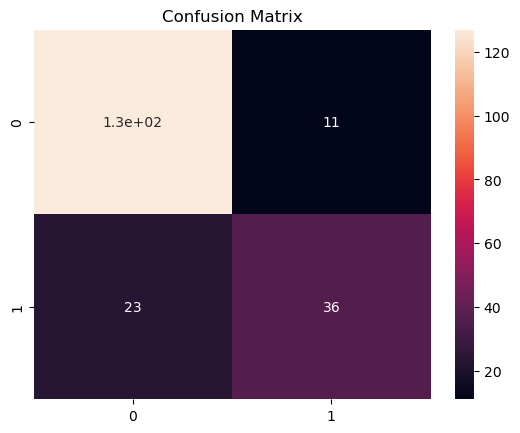

In [45]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.title("Confusion Matrix")
plt.show()

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 1.0


In [47]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 7.4 MB/s eta 0:00:14
   - -------------------------------------- 3.4/101.7 MB 7.7 MB/s eta 0:00:13
   - -------------------------------------- 5.0/101.7 MB 7.8 MB/s eta 0:00:13
   -- ------------------------------------- 6.6/101.7 MB 7.5 MB/s eta 0:00:13
   -- ------------------------------------- 7.6/101.7 MB 6.8 MB/s eta 0:00:14
   --- ------------------------------------ 8.1/101.7 MB 6.3 MB/s eta 0:00:15
   --- ------------------------------------ 8.9/101.7 MB 5.7 MB/s eta 0:00:17
   --- ------------------------------------ 9.4/101.7 MB 5.4 MB/s eta 0:00:18
   --- ------------------------------------ 10.0/101.7 MB 5.1 MB/s eta 0:00:19
   ---- ----------------------------------- 10.5/101.7 MB 4.7 MB/s eta 0:00:20
   ---- ----------------------------------- 11.0/101.7 MB 4.5 MB/s eta 0:00:

In [48]:
from xgboost import XGBClassifier

In [50]:
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [51]:
y_pred_xgb = xgb.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score

print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.8274111675126904


In [53]:
print("Logistic:", accuracy_score(y_test, y_pred))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))

Logistic: 0.8274111675126904
Random Forest: 1.0
XGBoost: 1.0


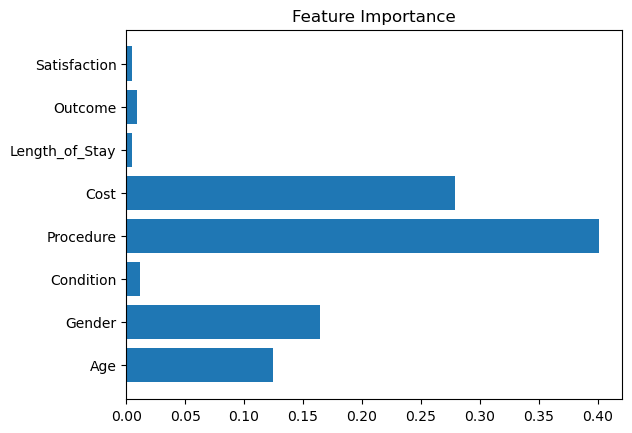

In [54]:
import matplotlib.pyplot as plt

importance = xgb.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()